In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

user_features = pd.read_csv('../data/processed/user_features.csv')
print(f"Loaded: {user_features.shape}")
print(f"\nColumns:")
for col in user_features.columns:
    print(f"  {col}")

Loaded: (962037, 23)

Columns:
  user_id
  total_plays
  unique_tracks
  unique_artists
  repeat_rate
  avg_danceability
  avg_energy
  avg_valence
  avg_acousticness
  avg_instrumentalness
  avg_speechiness
  avg_liveness
  avg_tempo
  avg_loudness
  genre_diversity
  avg_track_year
  artist_loyalty
  preferred_genre
  low_engagement
  cluster
  segment
  engagement_risk
  risk_tier


In [2]:
# CLV proxy = total_plays × (genre_diversity + 1) × avg_energy
#
# total_plays        -> raw volume of engagement (more listening = more value)
# (genre_diversity+1)-> breadth multiplier; +1 avoids zeroing out users
#                       whose tracks lack genre tags (genre_diversity=0)
# avg_energy         -> proxy for how "actively" they engage with content

user_features['clv_score'] = (
    user_features['total_plays'] *
    (user_features['genre_diversity'] + 1) *
    user_features['avg_energy']
)

# Normalise to 0-100 for readability
clv_min = user_features['clv_score'].min()
clv_max = user_features['clv_score'].max()
user_features['clv_score_norm'] = (
    (user_features['clv_score'] - clv_min) / (clv_max - clv_min) * 100
)

print(user_features['clv_score_norm'].describe().round(2))

count    962037.00
mean          0.58
std           1.33
min           0.00
25%           0.05
50%           0.17
75%           0.55
max         100.00
Name: clv_score_norm, dtype: float64


In [3]:
# rank-based qcut — guarantees unique bin edges even with skewed/zero-heavy data
user_features['clv_tier'] = pd.qcut(
    user_features['clv_score_norm'].rank(method='first'),
    q=2,
    labels=['Low CLV', 'High CLV']
)

print(user_features['clv_tier'].value_counts())
print(f"\nMedian CLV score: {user_features['clv_score_norm'].median():.2f}")

clv_tier
Low CLV     481019
High CLV    481018
Name: count, dtype: int64

Median CLV score: 0.17


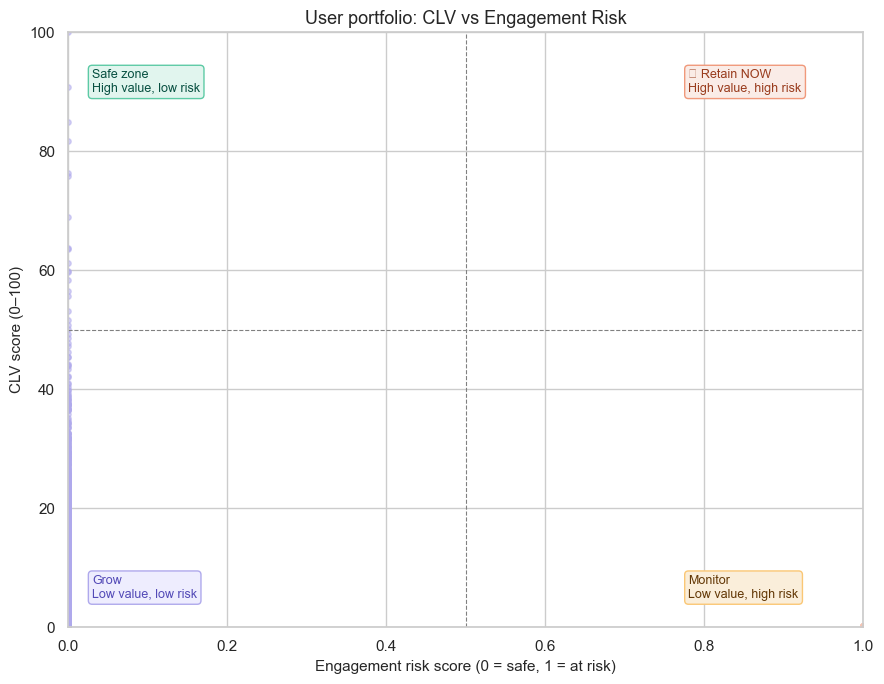

In [4]:
# Cell 4 — THE HERO CHART: CLV vs Engagement Risk (2×2 matrix)
# Top-right = High CLV + High Risk = most important to retain RIGHT NOW

fig, ax = plt.subplots(figsize=(9, 7))

colors_map = {
    ('Low CLV',  'Low risk')    : '#9FE1CB',
    ('Low CLV',  'Medium risk') : '#FAC775',
    ('Low CLV',  'High risk')   : '#F5C4B3',
    ('High CLV', 'Low risk')    : '#AFA9EC',
    ('High CLV', 'Medium risk') : '#FAC775',
    ('High CLV', 'High risk')   : '#D85A30',
}

for (clv, risk), grp in user_features.groupby(['clv_tier', 'risk_tier']):
    ax.scatter(
        grp['engagement_risk'],
        grp['clv_score_norm'],
        c=colors_map.get((clv, risk), 'gray'),
        alpha=0.5, s=15,
        label=f'{clv} · {risk}'
    )

# Quadrant lines
ax.axvline(0.5, color='gray', linestyle='--', linewidth=0.8)
ax.axhline(50,  color='gray', linestyle='--', linewidth=0.8)

# Quadrant labels
ax.text(0.78, 90, '⚠ Retain NOW\nHigh value, high risk',
        fontsize=9, color='#993C1D',
        bbox=dict(boxstyle='round', fc='#FAECE7', ec='#F0997B'))
ax.text(0.03, 90, 'Safe zone\nHigh value, low risk',
        fontsize=9, color='#085041',
        bbox=dict(boxstyle='round', fc='#E1F5EE', ec='#5DCAA5'))
ax.text(0.78, 5, 'Monitor\nLow value, high risk',
        fontsize=9, color='#633806',
        bbox=dict(boxstyle='round', fc='#FAEEDA', ec='#FAC775'))
ax.text(0.03, 5, 'Grow\nLow value, low risk',
        fontsize=9, color='#534AB7',
        bbox=dict(boxstyle='round', fc='#EEEDFE', ec='#AFA9EC'))

ax.set_xlabel('Engagement risk score (0 = safe, 1 = at risk)', fontsize=11)
ax.set_ylabel('CLV score (0–100)', fontsize=11)
ax.set_title('User portfolio: CLV vs Engagement Risk', fontsize=13)
ax.set_xlim(0, 1)
ax.set_ylim(0, 100)
plt.tight_layout()
plt.savefig('../data/processed/plot_clv_vs_risk.png', dpi=120)
plt.show()

In [5]:
priority = user_features[
    (user_features['clv_tier'] == 'High CLV') &
    (user_features['risk_tier'] == 'High risk')
].sort_values('engagement_risk', ascending=False)

print(f"High CLV + High Risk users: {len(priority):,}")
print(f"That's {len(priority)/len(user_features)*100:.1f}% of your user base")

print("\nTop 20 to contact this week:")
top20 = priority[['user_id', 'clv_score_norm', 'engagement_risk',
                  'segment', 'preferred_genre',
                  'total_plays', 'unique_artists']].head(20)
print(top20.to_string(index=False))

High CLV + High Risk users: 0
That's 0.0% of your user base

Top 20 to contact this week:
Empty DataFrame
Columns: [user_id, clv_score_norm, engagement_risk, segment, preferred_genre, total_plays, unique_artists]
Index: []


In [6]:
summary = user_features.groupby('segment').agg(
    num_users         = ('user_id',         'count'),
    avg_clv           = ('clv_score_norm',  'mean'),
    avg_risk          = ('engagement_risk', 'mean'),
    pct_high_risk     = ('risk_tier',       lambda x: (x=='High risk').mean()*100),
    avg_total_plays   = ('total_plays',     'mean'),
    avg_genre_div     = ('genre_diversity', 'mean'),
).round(1)

print("=== Segment Summary ===")
print(summary.to_string())

=== Segment Summary ===
                          num_users  avg_clv  avg_risk  pct_high_risk  avg_total_plays  avg_genre_div
segment                                                                                              
Casual Explorers             133155      2.6       0.0            0.0             92.5            4.3
Chill Acoustic Listeners     248907      0.3       0.3           34.0             15.1            1.4
Energetic Pop Fans           171422      0.2       0.3           31.0             15.4            1.6
Loyal Superfans              408553      0.3       0.2           23.9             16.7            1.9


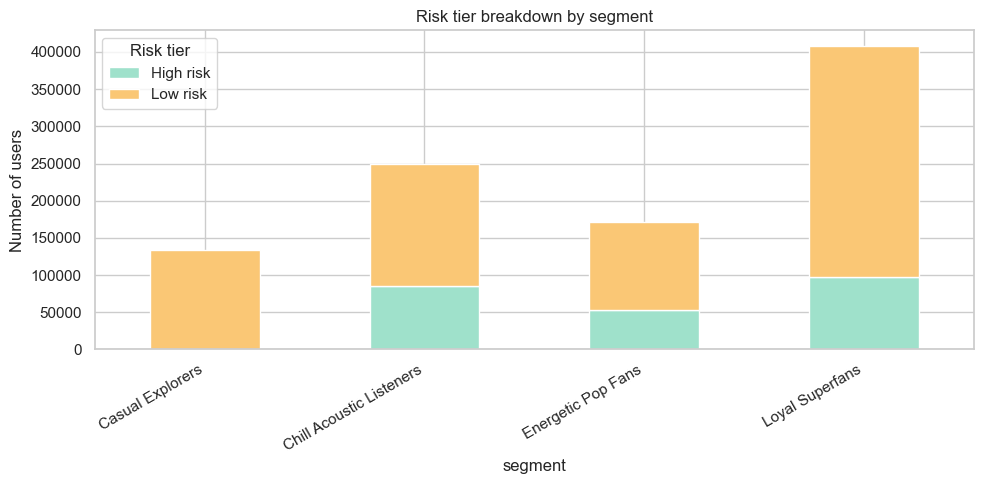

In [7]:
segment_risk = (
    user_features.groupby(['segment', 'risk_tier'])
    .size()
    .unstack(fill_value=0)
)

segment_risk.plot(kind='bar', stacked=True, figsize=(10, 5),
                  color=['#9FE1CB', '#FAC775', '#D85A30'],
                  edgecolor='white')
plt.title('Risk tier breakdown by segment')
plt.ylabel('Number of users')
plt.xticks(rotation=30, ha='right')
plt.legend(title='Risk tier')
plt.tight_layout()
plt.savefig('../data/processed/plot_segment_risk.png', dpi=120)
plt.show()

In [8]:
print("""
RECOMMENDATIONS BY QUADRANT
============================

HIGH CLV + HIGH RISK  ->  Retain NOW
  - Personalised "we miss you" push notification
  - 1-month premium discount
  - Curated playlist from their preferred_genre

HIGH CLV + LOW RISK  ->  Safe zone
  - Upsell to annual plan
  - Early access to new features / artist events

LOW CLV + LOW RISK  ->  Grow
  - Weekly discovery playlists
  - Social features (share, follow friends)

LOW CLV + HIGH RISK  ->  Monitor
  - Low investment - track but don't spend retention budget
""")


RECOMMENDATIONS BY QUADRANT

HIGH CLV + HIGH RISK  ->  Retain NOW
  - Personalised "we miss you" push notification
  - 1-month premium discount
  - Curated playlist from their preferred_genre

HIGH CLV + LOW RISK  ->  Safe zone
  - Upsell to annual plan
  - Early access to new features / artist events

LOW CLV + LOW RISK  ->  Grow
  - Weekly discovery playlists
  - Social features (share, follow friends)

LOW CLV + HIGH RISK  ->  Monitor
  - Low investment - track but don't spend retention budget



In [9]:
import os
os.makedirs('../dashboard/data', exist_ok=True)

# 1. Full profile — for your own records (not used by the dashboard)
user_features.to_csv('../data/processed/final_user_profiles.csv', index=False)

# 2. Small sample for scatter plots in the dashboard (~12-18K rows max)
dashboard_sample = (
    user_features
    .groupby(['clv_tier', 'risk_tier'], group_keys=False)
    .apply(lambda g: g.sample(min(len(g), 3000), random_state=42))
)
dashboard_sample.to_csv('../dashboard/data/user_sample.csv', index=False)

# 3. Segment summary table (tiny — one row per persona)
summary.reset_index().to_csv('../dashboard/data/segment_summary.csv', index=False)

# 4. Segment profile heatmap data
profile_cols = ['total_plays','unique_tracks','unique_artists','repeat_rate',
                'artist_loyalty','genre_diversity','avg_danceability',
                'avg_energy','avg_valence','clv_score_norm','engagement_risk']
profile = user_features.groupby('segment')[profile_cols].mean()
profile_norm = (profile - profile.min()) / (profile.max() - profile.min())
profile_norm.to_csv('../dashboard/data/cluster_profile.csv')

# 5. Priority retention list (naturally small — High CLV + High Risk only)
priority[['user_id','clv_score_norm','engagement_risk','segment',
          'preferred_genre','total_plays','unique_artists']] \
    .to_csv('../dashboard/data/priority_users.csv', index=False)

print("Dashboard data files saved:")
for f in os.listdir('../dashboard/data'):
    size_kb = os.path.getsize(f'../dashboard/data/{f}') / 1024
    print(f"  {f:25s} {size_kb:8.1f} KB")

Dashboard data files saved:
  cluster_profile.csv            0.7 KB
  priority_users.csv             0.1 KB
  segment_summary.csv            0.3 KB
  user_sample.csv             2332.1 KB
